In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(783.5), np.float64(484.5), np.float64(-0.5))

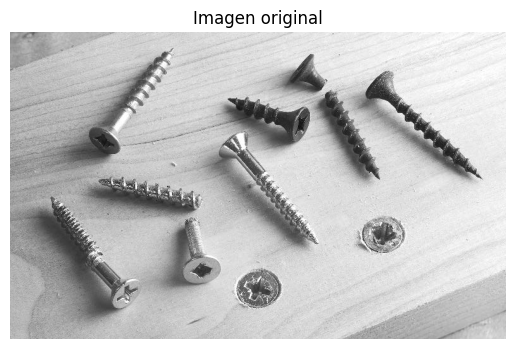

In [35]:
# Leer imagen en escala de grises
imagen = cv2.imread("img/tornillos_2.jpg", cv2.IMREAD_GRAYSCALE)

# Mostrar imagen
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

(np.float64(-0.5), np.float64(783.5), np.float64(484.5), np.float64(-0.5))

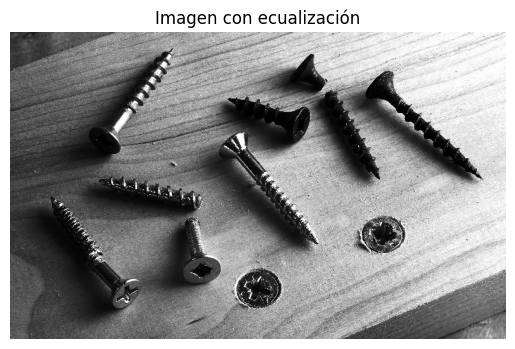

In [36]:
imagen_eq = cv2.equalizeHist(imagen)

plt.imshow(imagen_eq, cmap="gray")
plt.title("Imagen con ecualización")
plt.axis("off")

(np.float64(-0.5), np.float64(783.5), np.float64(484.5), np.float64(-0.5))

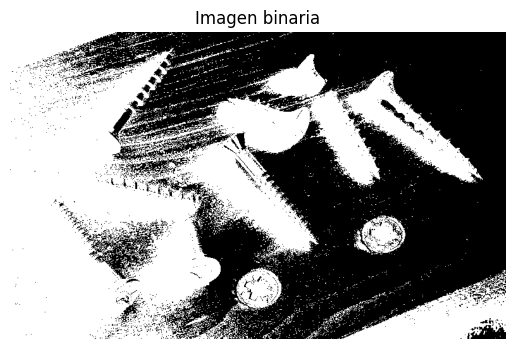

In [37]:
_, binaria = cv2.threshold(
    imagen_eq,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(binaria, cmap="gray")
plt.title("Imagen binaria")
plt.axis("off")

(np.float64(-0.5), np.float64(783.5), np.float64(484.5), np.float64(-0.5))

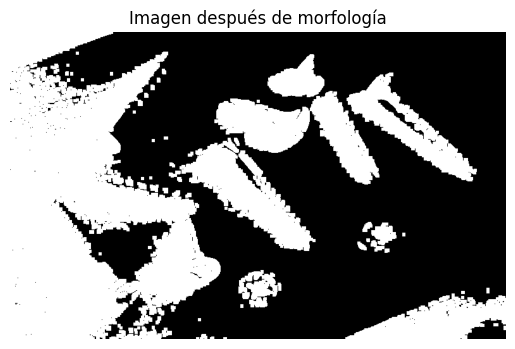

In [38]:
kernel = np.ones((3,3), np.uint8)

# Apertura morfológica (erosión + dilatación)
binaria_limpia = cv2.morphologyEx(
    binaria,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

plt.imshow(binaria_limpia, cmap="gray")
plt.title("Imagen después de morfología")
plt.axis("off")

In [39]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binaria_limpia,
    8,
    ltype=cv2.CV_32S
)

print("Número de componentes detectados:", num_labels)

Número de componentes detectados: 61


In [47]:
area_min = 150
contador = 0

imagen_color = cv2.cvtColor(imagen, cv2.COLOR_GRAY2BGR)

for i in range(1, num_labels):  # ignorar fondo
    area = stats[i, cv2.CC_STAT_AREA]

    if area > area_min:
        contador += 1
        
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        cv2.rectangle(imagen_color, (x,y), (x+w,y+h), (0,255,0), 2)

print("Número de tornillos detectados:", contador)

Número de tornillos detectados: 13


(np.float64(-0.5), np.float64(783.5), np.float64(484.5), np.float64(-0.5))

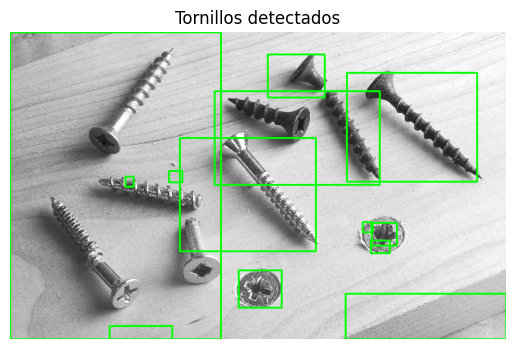

In [44]:
plt.imshow(cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB))
plt.title("Tornillos detectados")
plt.axis("off")